# Notebook 3: Modeling and analysis

This notebook trains and evaluates models on the model-ready datasets (base / queen / boundary), then performs ethics, bias, and error analysis using the saved **held-out test set** predictions.

### Inputs
- `datasets/model_ready/model_ready_base.csv`
- `datasets/model_ready/model_ready_queen.csv`
- `datasets/model_ready/model_ready_boundary.csv`

### Outputs (modeling)
- `datasets/model_ready/model_ready_*_train.csv` / `datasets/model_ready/model_ready_*_test.csv`
- `outputs/modeling/final_test_set_results.csv`
- `outputs/modeling/test_set_predictions_all_models.csv`

### Outputs (sensitivity)
- `outputs/modeling/sensitivity_reduced_final_test_set_results.csv`
- `outputs/modeling/sensitivity_reduced_comparison_table.csv`

### Outputs (ethics / bias / error)
- tables under `outputs/ethics_bias_error_analysis/`
- figures under `outputs/ethics_bias_error_analysis/figures/`


### Importing packages and models, settings & directories

In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("datasets/model_ready")
MODEL_OUT_DIR = Path("outputs") / "modeling"
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

ETHICS_OUT_DIR = Path("outputs") / "ethics_bias_error_analysis"
(ETHICS_OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

# XGBoost import
_libomp_candidates = [
    "/usr/local/opt/libomp/lib",
    "/opt/homebrew/opt/libomp/lib",
]
for p in _libomp_candidates:
    if os.path.isdir(p):
        os.environ["DYLD_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")
        os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_FALLBACK_LIBRARY_PATH", "")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(e)

print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", XGBOOST_IMPORT_ERROR)


XGBoost available: True


### Load model-ready datasets

In [2]:
BASE_PATH = DATA_DIR / "model_ready_base.csv"
QUEEN_PATH = DATA_DIR / "model_ready_queen.csv"
BOUNDARY_PATH = DATA_DIR / "model_ready_boundary.csv"

base_df_full = pd.read_csv(BASE_PATH, low_memory=False)
queen_df_full = pd.read_csv(QUEEN_PATH, low_memory=False)
boundary_df_full = pd.read_csv(BOUNDARY_PATH, low_memory=False)

print("base:", base_df_full.shape)
print("queen:", queen_df_full.shape)
print("boundary:", boundary_df_full.shape)


base: (14494, 92)
queen: (14494, 104)
boundary: (14494, 98)


### Held-out test split (municipality-grouped)

In [3]:
TARGET_COL = "log_crime_count"
GROUP_COL = "gm_naam"
TEST_FRACTION = 0.20

for tag, df in {"base": base_df_full, "queen": queen_df_full, "boundary": boundary_df_full}.items():
    if GROUP_COL not in df.columns:
        raise KeyError(f"Expected grouping column '{GROUP_COL}' in {tag} dataset.")
    if TARGET_COL not in df.columns:
        raise KeyError(f"Expected target '{TARGET_COL}' in {tag} dataset.")

base_munis = set(base_df_full[GROUP_COL].dropna().unique().tolist())
queen_munis = set(queen_df_full[GROUP_COL].dropna().unique().tolist())
boundary_munis = set(boundary_df_full[GROUP_COL].dropna().unique().tolist())

if not (base_munis == queen_munis == boundary_munis):
    raise ValueError("Municipality sets differ across datasets; cannot do a consistent grouped split.")

munis = sorted(base_munis)
rng = np.random.default_rng(RANDOM_STATE)

test_n_munis = max(1, int(round(TEST_FRACTION * len(munis))))
test_munis = set(rng.choice(munis, size=test_n_munis, replace=False).tolist())
train_munis = set(munis) - test_munis

print(f"Municipalities (train): {len(train_munis)} | (test): {len(test_munis)} | (total): {len(munis)}")


def split_by_muni(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    is_test = df[GROUP_COL].isin(test_munis)
    return df.loc[~is_test].copy(), df.loc[is_test].copy()

base_train_df, base_test_df = split_by_muni(base_df_full)
queen_train_df, queen_test_df = split_by_muni(queen_df_full)
boundary_train_df, boundary_test_df = split_by_muni(boundary_df_full)

print("Rows (train/test):")
print("- base:", base_train_df.shape, base_test_df.shape)
print("- queen:", queen_train_df.shape, queen_test_df.shape)
print("- boundary:", boundary_train_df.shape, boundary_test_df.shape)

# Save splits for reproducibility
base_train_df.to_csv(DATA_DIR / "model_ready_base_train.csv", index=False)
base_test_df.to_csv(DATA_DIR / "model_ready_base_test.csv", index=False)
queen_train_df.to_csv(DATA_DIR / "model_ready_queen_train.csv", index=False)
queen_test_df.to_csv(DATA_DIR / "model_ready_queen_test.csv", index=False)
boundary_train_df.to_csv(DATA_DIR / "model_ready_boundary_train.csv", index=False)
boundary_test_df.to_csv(DATA_DIR / "model_ready_boundary_test.csv", index=False)

print("Saved train/test splits under datasets/model_ready/")


Municipalities (train): 273 | (test): 68 | (total): 341
Rows (train/test):
- base: (11735, 92) (2759, 92)
- queen: (11735, 104) (2759, 104)
- boundary: (11735, 98) (2759, 98)
Saved train/test splits under datasets/model_ready/


### Feature selection

Numeric-only predictors, excluding identifiers, target-like columns, and leakage patterns.

In [4]:
ID_COLS_BASE = [
    "gwb_code_10",
    "gwb_code_8",
    "gwb_code",
    "ind_wbi",
    "merge_key",
    "regio",
    "gm_naam",
    "ID",
    "Perioden",
    "SoortMisdrijf",
    "recs",
    "centroid_x",
    "centroid_y",
]
ID_COLS_QUEEN = ID_COLS_BASE.copy()
ID_COLS_BOUNDARY = ID_COLS_BASE.copy()

RAW_TARGET_LIKE = {
    "crime_count",
    "crime_rate_per_1000",
    "GeregistreerdeMisdrijven_1",
}

LEAKAGE_PATTERNS = [
    r"spillover_spec",
    r"spillover_target",
    r"target_lag",
    r"lag_y",
    r"spillover_lag",
    r"lag_.*crime",
    r"crime.*lag",
]
LEAKAGE_REGEX = re.compile("|".join(LEAKAGE_PATTERNS), flags=re.IGNORECASE)


def select_numeric_predictors(df: pd.DataFrame, target: str, id_cols: List[str]) -> tuple[pd.DataFrame, pd.Series, Dict[str, Any]]:
    df = df.copy()

    leak = [c for c in df.columns if LEAKAGE_REGEX.search(c)]
    exclude = set([c for c in id_cols if c in df.columns]) | set(leak) | set([c for c in RAW_TARGET_LIKE if c in df.columns]) | {target}

    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    feature_cols = [c for c in num_cols if c not in exclude]

    X = df[feature_cols].copy()
    y = df[target].copy()

    info = {
        "n_features": int(X.shape[1]),
        "excluded_id_cols": [c for c in id_cols if c in df.columns],
        "excluded_leakage_cols": leak,
    }
    return X, y, info


X_base, y_base, _ = select_numeric_predictors(base_train_df, TARGET_COL, ID_COLS_BASE)
X_queen, y_queen, _ = select_numeric_predictors(queen_train_df, TARGET_COL, ID_COLS_QUEEN)
X_boundary, y_boundary, _ = select_numeric_predictors(boundary_train_df, TARGET_COL, ID_COLS_BOUNDARY)

X_base_test, y_base_test, _ = select_numeric_predictors(base_test_df, TARGET_COL, ID_COLS_BASE)
X_queen_test, y_queen_test, _ = select_numeric_predictors(queen_test_df, TARGET_COL, ID_COLS_QUEEN)
X_boundary_test, y_boundary_test, _ = select_numeric_predictors(boundary_test_df, TARGET_COL, ID_COLS_BOUNDARY)

# Align columns explicitly
X_base_test = X_base_test.reindex(columns=X_base.columns, fill_value=np.nan)
X_queen_test = X_queen_test.reindex(columns=X_queen.columns, fill_value=np.nan)
X_boundary_test = X_boundary_test.reindex(columns=X_boundary.columns, fill_value=np.nan)

print("Selected predictors:")
print("- base:", X_base.shape[1])
print("- queen:", X_queen.shape[1])
print("- boundary:", X_boundary.shape[1])


Selected predictors:
- base: 86
- queen: 98
- boundary: 92


### Dataset shape overview

In [5]:
# Dataset shape overview (train/test)

shape_rows = []
for ds, Xtr, Xte in [
    ("base", X_base, X_base_test),
    ("queen", X_queen, X_queen_test),
    ("boundary", X_boundary, X_boundary_test),
]:
    shape_rows.append(
        {
            "dataset": ds,
            "train_rows": int(Xtr.shape[0]),
            "train_features": int(Xtr.shape[1]),
            "test_rows": int(Xte.shape[0]),
            "test_features": int(Xte.shape[1]),
        }
    )

shape_df = pd.DataFrame(shape_rows)
display(shape_df)


,dataset,train_rows,train_features,test_rows,test_features
0,base,11735,86,2759,86
1,queen,11735,98,2759,98
2,boundary,11735,92,2759,92


In [6]:
# Target distribution summary (train/test)

def _target_summary(y: pd.Series) -> dict:
    y = pd.to_numeric(y, errors="coerce")
    return {
        "n": int(y.notna().sum()),
        "mean": float(y.mean()),
        "std": float(y.std()),
        "min": float(y.min()),
        "median": float(y.median()),
        "max": float(y.max()),
    }

rows = []
for ds, ytr, yte in [
    ("base", y_base, y_base_test),
    ("queen", y_queen, y_queen_test),
    ("boundary", y_boundary, y_boundary_test),
]:
    r_tr = {"dataset": ds, "split": "train"}
    r_tr.update(_target_summary(ytr))
    rows.append(r_tr)

    r_te = {"dataset": ds, "split": "test"}
    r_te.update(_target_summary(yte))
    rows.append(r_te)

target_summary_df = pd.DataFrame(rows)
display(target_summary_df.round(4))


,dataset,split,n,mean,std,min,median,max
0,base,train,11735,3.0971,1.4005,0.0,3.1355,8.2201
1,base,test,2759,3.0784,1.3832,0.0,3.1781,8.0077
2,queen,train,11735,3.0971,1.4005,0.0,3.1355,8.2201
3,queen,test,2759,3.0784,1.3832,0.0,3.1781,8.0077
4,boundary,train,11735,3.0971,1.4005,0.0,3.1355,8.2201
5,boundary,test,2759,3.0784,1.3832,0.0,3.1781,8.0077


### Building pipelines and CV

In [7]:
def make_ols_pipeline() -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )


def make_rf_pipeline() -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_xgb_pipeline() -> Pipeline:
    if not XGBOOST_AVAILABLE:
        raise ImportError(f"xgboost is not available. Import error was: {XGBOOST_IMPORT_ERROR}")
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                xgb.XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_lambda=1.0,
                    objective="reg:squarederror",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_cv(groups: Optional[pd.Series]) -> Tuple[Any, str]:
    if groups is not None:
        return GroupKFold(n_splits=5), f"GroupKFold(n_splits=5) on '{groups.name}'"
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), f"KFold(n_splits=5, shuffle=True, random_state={RANDOM_STATE})"


groups_base = base_train_df[GROUP_COL]
groups_queen = queen_train_df[GROUP_COL]
groups_boundary = boundary_train_df[GROUP_COL]

cv_base, cv_base_desc = make_cv(groups_base)
cv_queen, cv_queen_desc = make_cv(groups_queen)
cv_boundary, cv_boundary_desc = make_cv(groups_boundary)

print("CV:")
print("- base:", cv_base_desc)
print("- queen:", cv_queen_desc)
print("- boundary:", cv_boundary_desc)


CV:
- base: GroupKFold(n_splits=5) on 'gm_naam'
- queen: GroupKFold(n_splits=5) on 'gm_naam'
- boundary: GroupKFold(n_splits=5) on 'gm_naam'


### MVP CV (train split only) + final held-out test evaluation

Models: OLS, RF, XGB. Tuning happens on the training split only.

In [8]:
# 1. Evaluation functions

def calc_rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_cv_oof(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    groups: Optional[pd.Series],
    model_name: str,
    dataset_name: str,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    oof_pred = np.full(len(y), np.nan, dtype=float)
    fold_rows = []

    for fold, (tr, va) in enumerate(cv.split(X, y, groups)):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]

        model_fold = clone(model)
        model_fold.fit(X_tr, y_tr)

        pred_va = model_fold.predict(X_va)
        oof_pred[va] = pred_va

        fold_rows.append(
            {
                "dataset": dataset_name,
                "model": model_name,
                "fold": fold,
                "rmse_val": calc_rmse(y_va, pred_va),
                "mae_val": float(mean_absolute_error(y_va, pred_va)),
                "r2_val": float(r2_score(y_va, pred_va)),
            }
        )

    folds = pd.DataFrame(fold_rows)
    oof = pd.DataFrame({"dataset": dataset_name, "model": model_name, "y_true": y.values, "y_pred": oof_pred})
    return folds, oof


def fit_predict_eval(model: Pipeline, Xtr, ytr, Xte, yte):
    m = clone(model)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    return pred, calc_rmse(yte, pred), float(mean_absolute_error(yte, pred)), float(r2_score(yte, pred))


In [9]:
# 2. Model definitions

models: Dict[str, Pipeline] = {
    "OLS": make_ols_pipeline(),
    "RF": make_rf_pipeline(),
}
if XGBOOST_AVAILABLE:
    models["XGB"] = make_xgb_pipeline()
    print("XGBoost Available")
else:
    print("XGBoost NOT Available")


XGBoost Available


### Cross-validation comparison

In [10]:
# 3. Cross-validation comparison of MVP models

folds_all = []
oof_all = []

for name, pipe in models.items():
    f, o = evaluate_cv_oof(pipe, X_base, y_base, cv_base, groups_base, name, "base")
    folds_all.append(f)
    oof_all.append(o)

    f, o = evaluate_cv_oof(pipe, X_queen, y_queen, cv_queen, groups_queen, name, "queen")
    folds_all.append(f)
    oof_all.append(o)

    f, o = evaluate_cv_oof(pipe, X_boundary, y_boundary, cv_boundary, groups_boundary, name, "boundary")
    folds_all.append(f)
    oof_all.append(o)

folds_df = pd.concat(folds_all, ignore_index=True)
oof_df = pd.concat(oof_all, ignore_index=True)


In [11]:
# Cross-validation fold-level results (raw)

fold_level = folds_df[["dataset", "model", "fold", "rmse_val", "mae_val", "r2_val"]].copy()
fold_level = fold_level.sort_values(["dataset", "model", "fold"]).reset_index(drop=True)
display(fold_level.round(4))


,dataset,model,fold,rmse_val,mae_val,r2_val
0,base,OLS,0,0.7621,0.5502,0.7274
1,base,OLS,1,0.7308,0.5439,0.7131
2,base,OLS,2,0.7135,0.5354,0.7351
3,base,OLS,3,0.6942,0.5184,0.7519
4,base,OLS,4,0.7060,0.5380,0.7259
5,base,RF,0,0.6199,0.4443,0.8197
6,base,RF,1,0.6005,0.4400,0.8063
7,base,RF,2,0.6094,0.4435,0.8067
8,base,RF,3,0.5910,0.4344,0.8202
9,base,RF,4,0.5928,0.4354,0.8067


In [12]:
# 4. Cross-validation results summary (mean + std)

summary = (
    folds_df.groupby(["dataset", "model"])
    .agg(
        mean_rmse=("rmse_val", "mean"),
        std_rmse=("rmse_val", "std"),
        mean_mae=("mae_val", "mean"),
        std_mae=("mae_val", "std"),
        mean_r2=("r2_val", "mean"),
        std_r2=("r2_val", "std"),
    )
    .reset_index()
)

print("\nMVP CV summary (train split only):")
display(summary.sort_values("mean_rmse").round(4))



MVP CV summary (train split only):


,dataset,model,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2
8,queen,XGB,0.5765,0.0069,0.4247,0.0017,0.8277,0.0106
5,boundary,XGB,0.5813,0.0079,0.4264,0.0036,0.8249,0.0098
2,base,XGB,0.5820,0.0135,0.4253,0.0053,0.8245,0.0103
7,queen,RF,0.5963,0.0078,0.4390,0.0052,0.8157,0.0111
1,base,RF,0.6027,0.0120,0.4395,0.0045,0.8119,0.0073
4,boundary,RF,0.6029,0.0112,0.4402,0.0051,0.8118,0.0082
6,queen,OLS,0.7013,0.0251,0.5243,0.0103,0.7454,0.0129
3,boundary,OLS,0.7159,0.0273,0.5341,0.0124,0.7347,0.0157
0,base,OLS,0.7213,0.0264,0.5372,0.0120,0.7307,0.0143


### Hyperparameter tuning

In [13]:
# 5. Hyperparameter tuning function

# Tuning (RF/XGB) is done on the training split only

def run_random_search(
    estimator: Pipeline,
    param_grid: dict,
    X,
    y,
    cv,
    groups,
    n_iter: int,
    label: str,
):
    print(f"\n--- Tuning {label} ---")
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbose=1,
        return_train_score=True,
    )
    search.fit(X, y, **({"groups": groups} if groups is not None else {}))

    res = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    best_rmse = float(-search.best_score_)

    print("Best params:")
    print(search.best_params_)
    print(f"Best CV RMSE: {best_rmse:.4f}")

    return search.best_estimator_, res, best_rmse


In [14]:
# Show top tuning runs (+ train/validation RMSE gap)

def display_top_tuning_runs(res: pd.DataFrame, top_n: int = 10, title: str | None = None) -> pd.DataFrame:
    cols = [c for c in res.columns if c.startswith("param_")]
    show_cols = [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
    ] + cols

    out = res[show_cols].copy()

    # RandomizedSearchCV uses negative RMSE here (neg_root_mean_squared_error)
    out["train_rmse"] = -out["mean_train_score"]
    out["cv_rmse"] = -out["mean_test_score"]
    out["rmse_gap"] = out["cv_rmse"] - out["train_rmse"]

    out = out.sort_values("rank_test_score").head(top_n)

    if title is not None:
        print(title)

    display(out.round(4))
    return out


In [15]:
# 6. Random Forest tuning configuration

rf_param_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8],
    "model__bootstrap": [True],
}

rf_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)


In [16]:
# 7. Run Random Forest tuning

rf_best_base, rf_res_base, rf_cv_rmse_base = run_random_search(
    rf_pipe,
    rf_param_grid,
    X_base,
    y_base,
    cv_base,
    groups_base,
    n_iter=30,
    label="RF (base)",
)
rf_best_queen, rf_res_queen, rf_cv_rmse_queen = run_random_search(
    rf_pipe,
    rf_param_grid,
    X_queen,
    y_queen,
    cv_queen,
    groups_queen,
    n_iter=30,
    label="RF (queen)",
)
rf_best_boundary, rf_res_boundary, rf_cv_rmse_boundary = run_random_search(
    rf_pipe,
    rf_param_grid,
    X_boundary,
    y_boundary,
    cv_boundary,
    groups_boundary,
    n_iter=30,
    label="RF (boundary)",
)



--- Tuning RF (base) ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best CV RMSE: 0.5953

--- Tuning RF (queen) ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best CV RMSE: 0.5910

--- Tuning RF (boundary) ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:
{'model__n_estimators': 800, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 40, 'model__bootstrap': True}
Best CV RMSE: 0.5974


In [17]:
# Best tuning results tables (RF)

display_top_tuning_runs(rf_res_base, top_n=10, title="RF tuning (base) — top runs")
display_top_tuning_runs(rf_res_queen, top_n=10, title="RF tuning (queen) — top runs")
display_top_tuning_runs(rf_res_boundary, top_n=10, title="RF tuning (boundary) — top runs")


RF tuning (base) — top runs


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,param_model__bootstrap,train_rmse,cv_rmse,rmse_gap
24,1,-0.5953,0.0119,-0.2557,500,2,2,0.5,40,True,0.2557,0.5953,0.3396
8,1,-0.5953,0.0119,-0.2557,500,2,2,0.5,None,True,0.2557,0.5953,0.3396
9,3,-0.5965,0.0124,-0.3640,800,2,5,0.5,20,True,0.3640,0.5965,0.2325
18,4,-0.5967,0.0125,-0.3638,800,2,5,0.5,40,True,0.3638,0.5967,0.2329
29,5,-0.5968,0.0113,-0.2164,500,2,1,0.5,None,True,0.2164,0.5968,0.3804
1,6,-0.5980,0.0109,-0.2530,500,2,2,0.8,None,True,0.2530,0.5980,0.3451
21,7,-0.5982,0.0130,-0.3641,300,2,5,0.5,None,True,0.3641,0.5982,0.2341
5,8,-0.5985,0.0107,-0.2494,500,5,1,0.8,20,True,0.2494,0.5985,0.3491
20,9,-0.5985,0.0118,-0.3556,500,10,5,0.8,40,True,0.3556,0.5985,0.2429
22,10,-0.5988,0.0115,-0.2561,300,2,2,0.8,20,True,0.2561,0.5988,0.3428


RF tuning (queen) — top runs


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,param_model__bootstrap,train_rmse,cv_rmse,rmse_gap
24,1,-0.5910,0.0068,-0.2479,500,2,2,0.5,40,True,0.2479,0.5910,0.3431
8,1,-0.5910,0.0068,-0.2479,500,2,2,0.5,None,True,0.2479,0.5910,0.3431
29,3,-0.5918,0.0069,-0.2147,500,2,1,0.5,None,True,0.2147,0.5918,0.3770
9,4,-0.5920,0.0082,-0.3495,800,2,5,0.5,20,True,0.3495,0.5920,0.2425
18,5,-0.5920,0.0083,-0.3493,800,2,5,0.5,40,True,0.3493,0.5920,0.2427
1,6,-0.5930,0.0068,-0.2458,500,2,2,0.8,None,True,0.2458,0.5930,0.3472
21,7,-0.5930,0.0084,-0.3495,300,2,5,0.5,None,True,0.3495,0.5930,0.2435
5,8,-0.5933,0.0073,-0.2432,500,5,1,0.8,20,True,0.2432,0.5933,0.3501
22,9,-0.5934,0.0077,-0.2484,300,2,2,0.8,20,True,0.2484,0.5934,0.3450
20,10,-0.5936,0.0074,-0.3418,500,10,5,0.8,40,True,0.3418,0.5936,0.2518


RF tuning (boundary) — top runs


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,param_model__bootstrap,train_rmse,cv_rmse,rmse_gap
18,1,-0.5974,0.0126,-0.3570,800,2,5,0.5,40,True,0.3570,0.5974,0.2404
9,2,-0.5976,0.0125,-0.3573,800,2,5,0.5,20,True,0.3573,0.5976,0.2403
24,3,-0.5976,0.0116,-0.2519,500,2,2,0.5,40,True,0.2519,0.5976,0.3458
8,3,-0.5976,0.0116,-0.2519,500,2,2,0.5,None,True,0.2519,0.5976,0.3458
29,5,-0.5977,0.0117,-0.2165,500,2,1,0.5,None,True,0.2165,0.5977,0.3812
21,6,-0.5983,0.0127,-0.3574,300,2,5,0.5,None,True,0.3574,0.5983,0.2408
1,7,-0.5992,0.0109,-0.2500,500,2,2,0.8,None,True,0.2500,0.5992,0.3492
22,8,-0.5993,0.0111,-0.2526,300,2,2,0.8,20,True,0.2526,0.5993,0.3467
5,9,-0.5996,0.0108,-0.2469,500,5,1,0.8,20,True,0.2469,0.5996,0.3527
20,10,-0.5996,0.0114,-0.3494,500,10,5,0.8,40,True,0.3494,0.5996,0.2502


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,param_model__bootstrap,train_rmse,cv_rmse,rmse_gap
18,1,-0.597366,0.012566,-0.357002,800,2,5,0.5,40,True,0.357002,0.597366,0.240364
9,2,-0.597629,0.012526,-0.357295,800,2,5,0.5,20,True,0.357295,0.597629,0.240334
24,3,-0.597641,0.011555,-0.251876,500,2,2,0.5,40,True,0.251876,0.597641,0.345766
8,3,-0.597641,0.011555,-0.251876,500,2,2,0.5,None,True,0.251876,0.597641,0.345766
29,5,-0.597651,0.011731,-0.216471,500,2,1,0.5,None,True,0.216471,0.597651,0.381180
21,6,-0.598279,0.012693,-0.357438,300,2,5,0.5,None,True,0.357438,0.598279,0.240840
1,7,-0.599205,0.010893,-0.250009,500,2,2,0.8,None,True,0.250009,0.599205,0.349196
22,8,-0.599322,0.011079,-0.252641,300,2,2,0.8,20,True,0.252641,0.599322,0.346681
5,9,-0.599555,0.010835,-0.246881,500,5,1,0.8,20,True,0.246881,0.599555,0.352674
20,10,-0.599583,0.011446,-0.349409,500,10,5,0.8,40,True,0.349409,0.599583,0.250174


In [18]:
# 8. XGBoost tuning configuration

if XGBOOST_AVAILABLE:
    xgb_param_grid = {
        "model__n_estimators": [300, 500, 800, 1000],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__min_child_weight": [1, 3, 5, 10],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_alpha": [0, 0.01, 0.1, 1],
        "model__reg_lambda": [0.5, 1, 2, 5],
    }

    xgb_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                xgb.XGBRegressor(
                    objective="reg:squarederror",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


In [19]:
# 9. Run XGBoost tuning

if XGBOOST_AVAILABLE:
    xgb_best_base, xgb_res_base, xgb_cv_rmse_base = run_random_search(
        xgb_pipe,
        xgb_param_grid,
        X_base,
        y_base,
        cv_base,
        groups_base,
        n_iter=40,
        label="XGB (base)",
    )
    xgb_best_queen, xgb_res_queen, xgb_cv_rmse_queen = run_random_search(
        xgb_pipe,
        xgb_param_grid,
        X_queen,
        y_queen,
        cv_queen,
        groups_queen,
        n_iter=40,
        label="XGB (queen)",
    )
    xgb_best_boundary, xgb_res_boundary, xgb_cv_rmse_boundary = run_random_search(
        xgb_pipe,
        xgb_param_grid,
        X_boundary,
        y_boundary,
        cv_boundary,
        groups_boundary,
        n_iter=40,
        label="XGB (boundary)",
    )



--- Tuning XGB (base) ---
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params:
{'model__subsample': 0.6, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
Best CV RMSE: 0.5773

--- Tuning XGB (queen) ---
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params:
{'model__subsample': 0.6, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
Best CV RMSE: 0.5707

--- Tuning XGB (boundary) ---
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params:
{'model__subsample': 0.6, 'model__reg_lambda': 2, 'model__reg_alpha': 0.1, 'model__n_estimators': 800, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytre

In [20]:
# Best tuning results tables (XGB)

if XGBOOST_AVAILABLE:
    display_top_tuning_runs(xgb_res_base, top_n=10, title="XGB tuning (base) — top runs")
    display_top_tuning_runs(xgb_res_queen, top_n=10, title="XGB tuning (queen) — top runs")
    display_top_tuning_runs(xgb_res_boundary, top_n=10, title="XGB tuning (boundary) — top runs")


XGB tuning (base) — top runs


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__subsample,param_model__reg_lambda,param_model__reg_alpha,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__colsample_bytree,train_rmse,cv_rmse,rmse_gap
31,1,-0.5773,0.0095,-0.4544,0.6,1.0,0.10,1000,3,5,0.01,0.6,0.4544,0.5773,0.1230
35,2,-0.5777,0.0106,-0.2921,0.8,1.0,0.00,800,5,8,0.01,0.6,0.2921,0.5777,0.2856
25,3,-0.5780,0.0109,-0.3170,0.6,2.0,0.10,800,5,8,0.01,0.8,0.3170,0.5780,0.2610
21,4,-0.5784,0.0084,-0.3465,0.6,0.5,0.01,500,3,6,0.03,0.6,0.3465,0.5784,0.2320
14,5,-0.5785,0.0109,-0.4346,0.6,5.0,0.10,800,1,6,0.01,0.6,0.4346,0.5785,0.1438
15,6,-0.5791,0.0100,-0.4438,0.8,2.0,0.10,800,10,4,0.03,0.6,0.4438,0.5791,0.1353
7,7,-0.5794,0.0109,-0.2841,0.6,2.0,1.00,800,3,6,0.03,1.0,0.2841,0.5794,0.2953
5,8,-0.5794,0.0112,-0.2645,0.8,0.5,0.10,800,1,6,0.03,0.6,0.2645,0.5794,0.3150
18,9,-0.5802,0.0103,-0.4756,0.6,0.5,0.00,800,10,5,0.01,0.8,0.4756,0.5802,0.1046
26,10,-0.5809,0.0118,-0.4186,1.0,5.0,1.00,1000,10,6,0.01,0.8,0.4186,0.5809,0.1623


XGB tuning (queen) — top runs


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__subsample,param_model__reg_lambda,param_model__reg_alpha,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__colsample_bytree,train_rmse,cv_rmse,rmse_gap
31,1,-0.5707,0.0063,-0.4426,0.6,1.0,0.10,1000,3,5,0.01,0.6,0.4426,0.5707,0.1281
5,2,-0.5718,0.0057,-0.2444,0.8,0.5,0.10,800,1,6,0.03,0.6,0.2444,0.5718,0.3274
25,3,-0.5719,0.0056,-0.2986,0.6,2.0,0.10,800,5,8,0.01,0.8,0.2986,0.5719,0.2733
14,4,-0.5720,0.0078,-0.4219,0.6,5.0,0.10,800,1,6,0.01,0.6,0.4219,0.5720,0.1500
35,5,-0.5720,0.0061,-0.2727,0.8,1.0,0.00,800,5,8,0.01,0.6,0.2727,0.5720,0.2994
15,6,-0.5723,0.0077,-0.4296,0.8,2.0,0.10,800,10,4,0.03,0.6,0.4296,0.5723,0.1427
18,7,-0.5725,0.0063,-0.4653,0.6,0.5,0.00,800,10,5,0.01,0.8,0.4653,0.5725,0.1072
21,8,-0.5730,0.0055,-0.3284,0.6,0.5,0.01,500,3,6,0.03,0.6,0.3284,0.5730,0.2446
7,9,-0.5732,0.0079,-0.2636,0.6,2.0,1.00,800,3,6,0.03,1.0,0.2636,0.5732,0.3095
26,10,-0.5739,0.0070,-0.4053,1.0,5.0,1.00,1000,10,6,0.01,0.8,0.4053,0.5739,0.1687


XGB tuning (boundary) — top runs


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__subsample,param_model__reg_lambda,param_model__reg_alpha,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__colsample_bytree,train_rmse,cv_rmse,rmse_gap
25,1,-0.5761,0.0077,-0.3051,0.6,2.0,0.10,800,5,8,0.01,0.8,0.3051,0.5761,0.2711
31,2,-0.5764,0.0074,-0.4473,0.6,1.0,0.10,1000,3,5,0.01,0.6,0.4473,0.5764,0.1291
21,3,-0.5765,0.0074,-0.3343,0.6,0.5,0.01,500,3,6,0.03,0.6,0.3343,0.5765,0.2422
35,4,-0.5765,0.0083,-0.2787,0.8,1.0,0.00,800,5,8,0.01,0.6,0.2787,0.5765,0.2978
14,5,-0.5767,0.0102,-0.4271,0.6,5.0,0.10,800,1,6,0.01,0.6,0.4271,0.5767,0.1496
5,6,-0.5771,0.0085,-0.2500,0.8,0.5,0.10,800,1,6,0.03,0.6,0.2500,0.5771,0.3271
15,7,-0.5776,0.0084,-0.4347,0.8,2.0,0.10,800,10,4,0.03,0.6,0.4347,0.5776,0.1429
18,8,-0.5781,0.0087,-0.4700,0.6,0.5,0.00,800,10,5,0.01,0.8,0.4700,0.5781,0.1081
7,9,-0.5789,0.0066,-0.2700,0.6,2.0,1.00,800,3,6,0.03,1.0,0.2700,0.5789,0.3089
26,10,-0.5795,0.0105,-0.4101,1.0,5.0,1.00,1000,10,6,0.01,0.8,0.4101,0.5795,0.1694


In [21]:
from IPython.display import display

# Helper for short description
param_desc = {
    "model__n_estimators": "Number of trees",
    "model__max_features": "Fraction of features sampled at each split",
    "model__max_depth": "Maximum depth of tree",
    "model__min_samples_split": "Minimum samples to split node",
    "model__min_samples_leaf": "Minimum samples at leaf",
    "model__bootstrap": "Bootstrap samples",
    "model__learning_rate": "Shrinkage rate",
    "model__subsample": "Fraction of samples for each tree",
    "model__colsample_bytree": "Fraction of features per tree",
    "model__reg_lambda": "L2 regularization",
    "model__reg_alpha": "L1 regularization",
    "model__min_child_weight": "Minimum sum of instance weights",
}

# Random Forest hyperparameters (from modeling blocks)
rf_param_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8],
    "model__bootstrap": [True],
}
# XGBoost hyperparameters (from modeling blocks)
xgb_param_grid = {
    "model__n_estimators": [300, 500, 800, 1000],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__min_child_weight": [1, 3, 5, 10],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_alpha": [0, 0.01, 0.1, 1],
        "model__reg_lambda": [0.5, 1, 2, 5],
}

rows = []

for param, rng in rf_param_grid.items():
    rows.append({
        "Model": "Random Forest",
        "Parameter": param.replace("model__", ""),
        "Range": str(rng),
        "Description": param_desc.get(param, ""),
    })

for param, rng in xgb_param_grid.items():
    rows.append({
        "Model": "XGBoost",
        "Parameter": param.replace("model__", ""),
        "Range": str(rng),
        "Description": param_desc.get(param, ""),
    })

# Format dataframe
param_table_df = pd.DataFrame(rows)
param_table_df = param_table_df[["Model", "Parameter", "Range", "Description"]]

# Display as DataFrame
display(param_table_df)

# Export as CSV
param_table_df.to_csv("outputs/modeling/hyperparam_table.csv", index=False)

,Model,Parameter,Range,Description
0,Random Forest,n_estimators,"[300, 500, 800]",Number of trees
1,Random Forest,max_depth,"[None, 10, 20, 40]",Maximum depth of tree
2,Random Forest,min_samples_split,"[2, 5, 10]",Minimum samples to split node
3,Random Forest,min_samples_leaf,"[1, 2, 5, 10]",Minimum samples at leaf
4,Random Forest,max_features,"['sqrt', 'log2', 0.5, 0.8]",Fraction of features sampled at each split
5,Random Forest,bootstrap,[True],Bootstrap samples
6,XGBoost,n_estimators,"[300, 500, 800, 1000]",Number of trees
7,XGBoost,learning_rate,"[0.01, 0.03, 0.05, 0.1]",Shrinkage rate
8,XGBoost,max_depth,"[3, 4, 5, 6, 8]",Maximum depth of tree
9,XGBoost,min_child_weight,"[1, 3, 5, 10]",Minimum sum of instance weights


### Optimal tuned hyperparameters (RF & XGB by feature set)

In [22]:
# Export optimal tuned hyperparameters (one row per model × feature set)

def _params_from_cv_results(res: pd.DataFrame) -> tuple[dict, float | None]:
    """Best row from RandomizedSearchCV.cv_results_ (rank_test_score == 1)."""
    best = res.loc[res["rank_test_score"] == 1].iloc[0]
    params = {
        k.replace("param_", ""): best[k]
        for k in res.columns
        if k.startswith("param_")
    }
    cv_rmse = float(-best["mean_test_score"]) if "mean_test_score" in best.index else None
    return params, cv_rmse


def _params_from_pipeline(pipe) -> dict:
    """Model-step hyperparameters from a fitted tuned Pipeline."""
    model = pipe.named_steps["model"]
    return {k: model.get_params()[k] for k in model.get_params()}


def _collect_tuned_config(model: str, dataset: str, res_name: str, pipe_name: str) -> dict | None:
    g = globals()
    row: dict = {"model": model, "dataset": dataset}

    if res_name in g and g[res_name] is not None:
        params, cv_rmse = _params_from_cv_results(g[res_name])
        row.update(params)
        if cv_rmse is not None:
            row["cv_rmse"] = cv_rmse
        return row

    if pipe_name in g and g[pipe_name] is not None:
        row.update(_params_from_pipeline(g[pipe_name]))
        return row

    return None


tuning_sources = [
    ("RF", "base", "rf_res_base", "rf_best_base"),
    ("RF", "queen", "rf_res_queen", "rf_best_queen"),
    ("RF", "boundary", "rf_res_boundary", "rf_best_boundary"),
]
if XGBOOST_AVAILABLE:
    tuning_sources += [
        ("XGB", "base", "xgb_res_base", "xgb_best_base"),
        ("XGB", "queen", "xgb_res_queen", "xgb_best_queen"),
        ("XGB", "boundary", "xgb_res_boundary", "xgb_best_boundary"),
    ]

params_rows = []
missing = []
for model, dataset, res_name, pipe_name in tuning_sources:
    row = _collect_tuned_config(model, dataset, res_name, pipe_name)
    if row is None:
        missing.append(f"{model}/{dataset} ({res_name} or {pipe_name})")
        continue
    params_rows.append(row)

if not params_rows:
    print("No tuned configurations found in memory.")
    print("Re-run the RF/XGB RandomizedSearchCV cells first, then re-run this cell.")
    if missing:
        print("Missing:", ", ".join(missing))
else:
    final_hyperparams_df = pd.DataFrame(params_rows)
    lead_cols = ["dataset", "model"]
    other_cols = sorted(c for c in final_hyperparams_df.columns if c not in lead_cols)
    final_hyperparams_df = final_hyperparams_df[lead_cols + other_cols]

    display(final_hyperparams_df)

    tuned_hyper_out = MODEL_OUT_DIR / "final_tuned_hyperparameters.csv"
    final_hyperparams_df.to_csv(tuned_hyper_out, index=False)
    print("Saved:", tuned_hyper_out)

if missing:
    print("Skipped (not in kernel):", ", ".join(missing))


,dataset,model,cv_rmse,model__bootstrap,model__colsample_bytree,model__learning_rate,model__max_depth,model__max_features,model__min_child_weight,model__min_samples_leaf,model__min_samples_split,model__n_estimators,model__reg_alpha,model__reg_lambda,model__subsample
0,base,RF,0.595346,True,NaN,NaN,40,0.5,NaN,2.0,2.0,500,NaN,NaN,NaN
1,queen,RF,0.590993,True,NaN,NaN,40,0.5,NaN,2.0,2.0,500,NaN,NaN,NaN
2,boundary,RF,0.597366,True,NaN,NaN,40,0.5,NaN,5.0,2.0,800,NaN,NaN,NaN
3,base,XGB,0.577340,NaN,0.6,0.01,5,NaN,3.0,NaN,NaN,1000,0.1,1.0,0.6
4,queen,XGB,0.570701,NaN,0.6,0.01,5,NaN,3.0,NaN,NaN,1000,0.1,1.0,0.6
5,boundary,XGB,0.576144,NaN,0.8,0.01,8,NaN,5.0,NaN,NaN,800,0.1,2.0,0.6


Saved: outputs/modeling/final_tuned_hyperparameters.csv


## Final Test-set Model Evaluation

### MVP Models

In [23]:
# Final test-set evaluation of MVP models

results = []
preds = []

ds_map = {
    "base": (X_base, y_base, X_base_test, y_base_test, base_test_df),
    "queen": (X_queen, y_queen, X_queen_test, y_queen_test, queen_test_df),
    "boundary": (X_boundary, y_boundary, X_boundary_test, y_boundary_test, boundary_test_df),
}

for ds, (Xtr, ytr, Xte, yte, test_df) in ds_map.items():
    for model_name, pipe in models.items():
        pred, _rmse, _mae, _r2 = fit_predict_eval(pipe, Xtr, ytr, Xte, yte)

        results.append(
            {
                "model": model_name,
                "dataset": ds,
                "tuning": "mvp",
                "rmse": _rmse,
                "mae": _mae,
                "r2": _r2,
            }
        )

        dfp = test_df[[c for c in ["gwb_code_10", "gm_naam", "regio"] if c in test_df.columns]].copy()
        dfp["dataset"] = ds
        dfp["model"] = model_name
        dfp["tuning"] = "mvp"
        dfp["y_true"] = yte.values
        dfp["y_pred"] = pred
        dfp["residual"] = dfp["y_true"] - dfp["y_pred"]
        dfp["abs_error"] = dfp["residual"].abs()
        preds.append(dfp)


### Tuned Models

In [24]:
# Final test-set evaluation of tuned models

for ds, (Xtr, ytr, Xte, yte, test_df) in ds_map.items():
    # Tuned RF
    pred, _rmse, _mae, _r2 = fit_predict_eval(
        {"base": rf_best_base, "queen": rf_best_queen, "boundary": rf_best_boundary}[ds],
        Xtr,
        ytr,
        Xte,
        yte,
    )
    results.append({"model": "RF", "dataset": ds, "tuning": "tuned", "rmse": _rmse, "mae": _mae, "r2": _r2})

    dfp = test_df[[c for c in ["gwb_code_10", "gm_naam", "regio"] if c in test_df.columns]].copy()
    dfp["dataset"] = ds
    dfp["model"] = "RF"
    dfp["tuning"] = "tuned"
    dfp["y_true"] = yte.values
    dfp["y_pred"] = pred
    dfp["residual"] = dfp["y_true"] - dfp["y_pred"]
    dfp["abs_error"] = dfp["residual"].abs()
    preds.append(dfp)

    # Tuned XGB (if available)
    if XGBOOST_AVAILABLE:
        pred, _rmse, _mae, _r2 = fit_predict_eval(
            {"base": xgb_best_base, "queen": xgb_best_queen, "boundary": xgb_best_boundary}[ds],
            Xtr,
            ytr,
            Xte,
            yte,
        )
        results.append({"model": "XGB", "dataset": ds, "tuning": "tuned", "rmse": _rmse, "mae": _mae, "r2": _r2})

        dfp = test_df[[c for c in ["gwb_code_10", "gm_naam", "regio"] if c in test_df.columns]].copy()
        dfp["dataset"] = ds
        dfp["model"] = "XGB"
        dfp["tuning"] = "tuned"
        dfp["y_true"] = yte.values
        dfp["y_pred"] = pred
        dfp["residual"] = dfp["y_true"] - dfp["y_pred"]
        dfp["abs_error"] = dfp["residual"].abs()
        preds.append(dfp)


In [25]:
# Save final model results and predictions

final_results_df = pd.DataFrame(results)
final_results_path = MODEL_OUT_DIR / "final_test_set_results.csv"
final_results_path.parent.mkdir(parents=True, exist_ok=True)
final_results_df.to_csv(final_results_path, index=False)

preds_df = pd.concat(preds, ignore_index=True)
preds_path = MODEL_OUT_DIR / "test_set_predictions_all_models.csv"
preds_df.to_csv(preds_path, index=False)

print("Saved:")
print("-", final_results_path)
print("-", preds_path)

Saved:
- outputs/modeling/final_test_set_results.csv
- outputs/modeling/test_set_predictions_all_models.csv


### RMSE Pivot table

In [26]:
# Final results RMSE pivot table

rmse_pivot = (
    final_results_df.assign(model_tuning=lambda d: d["model"] + " (" + d["tuning"] + ")")
    .pivot_table(index="dataset", columns="model_tuning", values="rmse", aggfunc="first")
)

rmse_pivot = rmse_pivot.reindex(index=["base", "queen", "boundary"])
display(rmse_pivot.round(4))

pivot_out = MODEL_OUT_DIR / "final_test_set_rmse_pivot.csv"
rmse_pivot.to_csv(pivot_out)
print("Saved:", pivot_out)


model_tuning,OLS (mvp),RF (mvp),RF (tuned),XGB (mvp),XGB (tuned)
dataset,,,,,
base,0.6842,0.5766,0.5732,0.5608,0.558
queen,0.6769,0.5842,0.5816,0.5656,0.561
boundary,0.6830,0.5779,0.5776,0.5625,0.556


Saved: outputs/modeling/final_test_set_rmse_pivot.csv


### Improvements

In [27]:
# Improvement table vs base (queen/boundary compared to base)

rows = []
for (model, tuning), g in final_results_df.groupby(["model", "tuning"]):
    base_rmse = g.loc[g["dataset"].eq("base"), "rmse"]
    if base_rmse.empty:
        continue
    base_rmse = float(base_rmse.iloc[0])

    for _, r in g.iterrows():
        current_rmse = float(r["rmse"])
        diff = current_rmse - base_rmse
        rows.append(
            {
                "model": model,
                "tuning": tuning,
                "dataset": r["dataset"],
                "rmse": current_rmse,
                "base_rmse": base_rmse,
                "rmse_difference": diff,
                "percent_change": diff / base_rmse * 100.0,
            }
        )

vs_base_df = pd.DataFrame(rows)
vs_base_df = vs_base_df.sort_values(["model", "tuning", "dataset"]).reset_index(drop=True)
display(vs_base_df.round(4))

vs_base_out = MODEL_OUT_DIR / "final_test_set_rmse_vs_base.csv"
vs_base_df.to_csv(vs_base_out, index=False)
print("Saved:", vs_base_out)


,model,tuning,dataset,rmse,base_rmse,rmse_difference,percent_change
0,OLS,mvp,base,0.6842,0.6842,0.0000,0.0000
1,OLS,mvp,boundary,0.6830,0.6842,-0.0012,-0.1781
2,OLS,mvp,queen,0.6769,0.6842,-0.0073,-1.0656
3,RF,mvp,base,0.5766,0.5766,0.0000,0.0000
4,RF,mvp,boundary,0.5779,0.5766,0.0013,0.2249
5,RF,mvp,queen,0.5842,0.5766,0.0077,1.3321
6,RF,tuned,base,0.5732,0.5732,0.0000,0.0000
7,RF,tuned,boundary,0.5776,0.5732,0.0044,0.7675
8,RF,tuned,queen,0.5816,0.5732,0.0084,1.4597
9,XGB,mvp,base,0.5608,0.5608,0.0000,0.0000


Saved: outputs/modeling/final_test_set_rmse_vs_base.csv


In [28]:
# MVP vs tuned improvement table (held-out test)

pairs = []
for ds in final_results_df["dataset"].unique():
    for model in final_results_df["model"].unique():
        mvp = final_results_df[(final_results_df["dataset"] == ds) & (final_results_df["model"] == model) & (final_results_df["tuning"] == "mvp")]
        tuned = final_results_df[(final_results_df["dataset"] == ds) & (final_results_df["model"] == model) & (final_results_df["tuning"] == "tuned")]
        if mvp.empty or tuned.empty:
            continue

        mvp_rmse = float(mvp.iloc[0]["rmse"])
        tuned_rmse = float(tuned.iloc[0]["rmse"])
        diff = tuned_rmse - mvp_rmse

        pairs.append(
            {
                "dataset": ds,
                "model": model,
                "mvp_rmse": mvp_rmse,
                "tuned_rmse": tuned_rmse,
                "rmse_difference": diff,
                "percent_change": diff / mvp_rmse * 100.0,
            }
        )

mvp_vs_tuned_df = pd.DataFrame(pairs).sort_values(["dataset", "model"]).reset_index(drop=True)
display(mvp_vs_tuned_df.round(4))

mvp_vs_tuned_out = MODEL_OUT_DIR / "final_test_set_rmse_mvp_vs_tuned.csv"
mvp_vs_tuned_df.to_csv(mvp_vs_tuned_out, index=False)
print("Saved:", mvp_vs_tuned_out)

,dataset,model,mvp_rmse,tuned_rmse,rmse_difference,percent_change
0,base,RF,0.5766,0.5732,-0.0033,-0.5788
1,base,XGB,0.5608,0.5580,-0.0028,-0.4956
2,boundary,RF,0.5779,0.5776,-0.0002,-0.0405
3,boundary,XGB,0.5625,0.5560,-0.0065,-1.1523
4,queen,RF,0.5842,0.5816,-0.0027,-0.4537
5,queen,XGB,0.5656,0.5610,-0.0047,-0.8290


Saved: outputs/modeling/final_test_set_rmse_mvp_vs_tuned.csv


### Best-performing model

In [29]:
# Best model per dataset (lowest test RMSE)

best_per_dataset = (
    final_results_df.sort_values("rmse")
    .groupby("dataset", as_index=False)
    .head(1)
    .loc[:, ["dataset", "model", "tuning", "rmse", "mae", "r2"]]
)

best_per_dataset = best_per_dataset.sort_values("dataset").reset_index(drop=True)
display(best_per_dataset.round(4))

best_per_dataset_out = MODEL_OUT_DIR / "best_model_per_dataset.csv"
best_per_dataset.to_csv(best_per_dataset_out, index=False)
print("Saved:", best_per_dataset_out)


,dataset,model,tuning,rmse,mae,r2
0,base,XGB,tuned,0.558,0.4087,0.8372
1,boundary,XGB,tuned,0.556,0.4050,0.8384
2,queen,XGB,tuned,0.561,0.4077,0.8355


Saved: outputs/modeling/best_model_per_dataset.csv


In [30]:
# Best dataset per model/tuning (lowest test RMSE)

best_dataset_per_model = (
    final_results_df.sort_values("rmse")
    .groupby(["model", "tuning"], as_index=False)
    .head(1)
    .loc[:, ["model", "tuning", "dataset", "rmse", "mae", "r2"]]
)

best_dataset_per_model = best_dataset_per_model.sort_values(["model", "tuning"]).reset_index(drop=True)
display(best_dataset_per_model.round(4))

best_dataset_per_model_out = MODEL_OUT_DIR / "best_dataset_per_model.csv"
best_dataset_per_model.to_csv(best_dataset_per_model_out, index=False)
print("Saved:", best_dataset_per_model_out)


,model,tuning,dataset,rmse,mae,r2
0,OLS,mvp,queen,0.6769,0.5131,0.7604
1,RF,mvp,base,0.5766,0.4206,0.8262
2,RF,tuned,base,0.5732,0.4182,0.8282
3,XGB,mvp,base,0.5608,0.4096,0.8356
4,XGB,tuned,boundary,0.5560,0.4050,0.8384


Saved: outputs/modeling/best_dataset_per_model.csv


In [31]:
# 13. Final model ranking on held-out test set

display(final_results_df.sort_values("rmse").head(15))


,model,dataset,tuning,rmse,mae,r2
14,XGB,boundary,tuned,0.556001,0.404970,0.838371
10,XGB,base,tuned,0.557991,0.408662,0.837212
2,XGB,base,mvp,0.560770,0.409555,0.835586
12,XGB,queen,tuned,0.560954,0.407705,0.835479
8,XGB,boundary,mvp,0.562482,0.410221,0.834581
5,XGB,queen,mvp,0.565643,0.408998,0.832717
9,RF,base,tuned,0.573230,0.418183,0.828199
1,RF,base,mvp,0.576567,0.420616,0.826193
13,RF,boundary,tuned,0.577629,0.420134,0.825552
7,RF,boundary,mvp,0.577864,0.419622,0.825410


### SHAP


Saved SHAP feature importance: outputs/modeling/shap_importance_xgb_boundary.csv


/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_41809/2793156712.py:42: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_s, feature_names=feature_names, show=False)


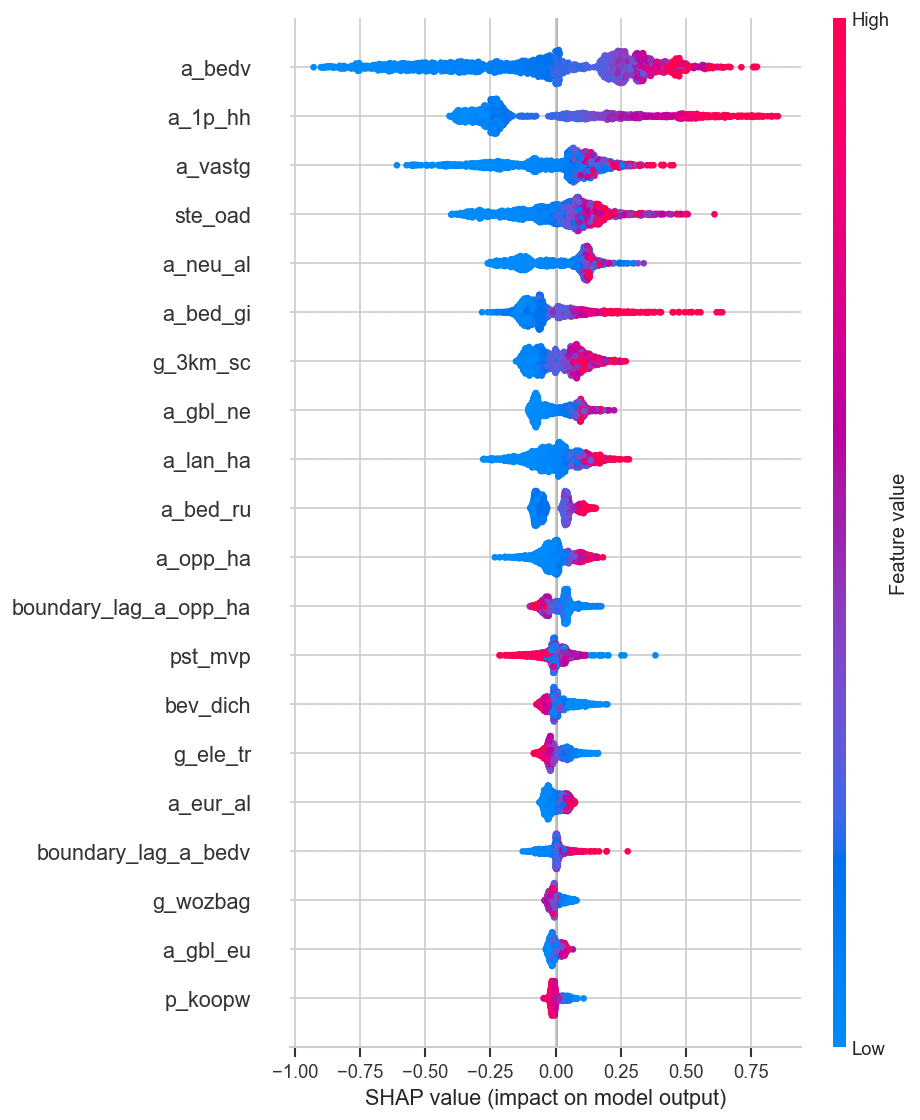

Saved SHAP summary plot: outputs/modeling/shap_summary_xgb_boundary.png
Saved top-15 SHAP feature importance: outputs/modeling/shap_top_features_xgb_boundary.csv
Saved base vs boundary-lag SHAP comparison: outputs/modeling/shap_base_vs_boundary_lag_xgb_boundary.csv


In [32]:
if XGBOOST_AVAILABLE:
    try:
        import shap  # type: ignore

        # Compute SHAP values and feature importance for tuned XGB on boundary
        from sklearn.base import clone

        # Fit the best tuned XGB on boundary data
        model_pipe = clone(xgb_best_boundary)
        model_pipe.fit(X_boundary, y_boundary)

        # Get imputed test data
        imputer = model_pipe.named_steps["imputer"]
        model = model_pipe.named_steps["model"]
        X_imp = imputer.transform(X_boundary_test)

        # Use a sample for SHAP for speed, if large
        rng = np.random.RandomState(RANDOM_STATE)
        n = X_imp.shape[0]
        sample_n = min(2000, n)
        idx = rng.choice(n, size=sample_n, replace=False)
        X_s = X_imp[idx]
        feature_names = list(X_boundary_test.columns)

        # SHAP explain
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_s)

        # Calculate mean absolute SHAP value per feature
        shap_importance = pd.DataFrame({
            "feature": feature_names,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0)
        }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

        # Export the feature importance table for tuned XGB on boundary
        shap_imp_out = MODEL_OUT_DIR / "shap_importance_xgb_boundary.csv"
        shap_importance.to_csv(shap_imp_out, index=False)
        print("Saved SHAP feature importance:", shap_imp_out)

        # Show and export summary plot
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_s, feature_names=feature_names, show=False)
        plot_outfile = MODEL_OUT_DIR / "shap_summary_xgb_boundary.png"
        plt.tight_layout()
        plt.savefig(plot_outfile)
        plt.show()
        print("Saved SHAP summary plot:", plot_outfile)

        # Export top-n SHAP features as a table
        top_n = 15
        shap_top_out = MODEL_OUT_DIR / "shap_top_features_xgb_boundary.csv"
        shap_importance.head(top_n).to_csv(shap_top_out, index=False)
        print(f"Saved top-{top_n} SHAP feature importance:", shap_top_out)

        # Table: compare base features vs boundary-lag features (assuming features containing "_lag" are lag variables)
        shap_importance["type"] = shap_importance["feature"].apply(lambda x: "boundary-lag" if "_lag" in x else "base")
        bound_lag_importance = shap_importance.groupby("type")["mean_abs_shap"].sum().reset_index()
        bound_lag_imp_out = MODEL_OUT_DIR / "shap_base_vs_boundary_lag_xgb_boundary.csv"
        bound_lag_importance.to_csv(bound_lag_imp_out, index=False)
        print("Saved base vs boundary-lag SHAP comparison:", bound_lag_imp_out)

    except Exception as ex:
        print("Skipping SHAP (unavailable or failed):", repr(ex))
else:
    print("Skipping SHAP: XGBoost not available.")


In [33]:
# Print the top 20 SHAP values for the best-performing model as a table (tuned XGB on boundary, if available)
try:
    best_shap_path = MODEL_OUT_DIR / "shap_importance_xgb_boundary.csv"
    if best_shap_path.exists():
        shap_df = pd.read_csv(best_shap_path)
        print("Top 20 SHAP values (tuned XGB on boundary):")
        display(shap_df.head(20))
    else:
        print("SHAP importance file not found:", best_shap_path)
except Exception as ex:
    print("Unable to print SHAP table:", repr(ex))

Top 20 SHAP values (tuned XGB on boundary):


,feature,mean_abs_shap
0,a_bedv,0.301884
1,a_1p_hh,0.280894
2,a_vastg,0.136429
3,ste_oad,0.121046
4,a_neu_al,0.116191
5,a_bed_gi,0.095659
6,g_3km_sc,0.077430
7,a_gbl_ne,0.070808
8,a_lan_ha,0.070684
9,a_bed_ru,0.063110


### Sensitivity analysis on reduced feature sets


In [34]:
RED_BASE_PATH = DATA_DIR / "model_ready_base_reduced.csv"
RED_QUEEN_PATH = DATA_DIR / "model_ready_queen_reduced.csv"
RED_BOUNDARY_PATH = DATA_DIR / "model_ready_boundary_reduced.csv"

base_red_full = pd.read_csv(RED_BASE_PATH, low_memory=False)
queen_red_full = pd.read_csv(RED_QUEEN_PATH, low_memory=False)
boundary_red_full = pd.read_csv(RED_BOUNDARY_PATH, low_memory=False)

base_train_red, base_test_red = split_by_muni(base_red_full)
queen_train_red, queen_test_red = split_by_muni(queen_red_full)
boundary_train_red, boundary_test_red = split_by_muni(boundary_red_full)

X_base_red, y_base_red, _ = select_numeric_predictors(base_train_red, TARGET_COL, ID_COLS_BASE)
X_queen_red, y_queen_red, _ = select_numeric_predictors(queen_train_red, TARGET_COL, ID_COLS_QUEEN)
X_boundary_red, y_boundary_red, _ = select_numeric_predictors(boundary_train_red, TARGET_COL, ID_COLS_BOUNDARY)

X_base_test_red, y_base_test_red, _ = select_numeric_predictors(base_test_red, TARGET_COL, ID_COLS_BASE)
X_queen_test_red, y_queen_test_red, _ = select_numeric_predictors(queen_test_red, TARGET_COL, ID_COLS_QUEEN)
X_boundary_test_red, y_boundary_test_red, _ = select_numeric_predictors(boundary_test_red, TARGET_COL, ID_COLS_BOUNDARY)

X_base_test_red = X_base_test_red.reindex(columns=X_base_red.columns, fill_value=np.nan)
X_queen_test_red = X_queen_test_red.reindex(columns=X_queen_red.columns, fill_value=np.nan)
X_boundary_test_red = X_boundary_test_red.reindex(columns=X_boundary_red.columns, fill_value=np.nan)

results_red = []

# Evaluate tuned best models on reduced (refit on reduced train)
for ds, (best_rf, best_xgb, Xtr, ytr, Xte, yte) in {
    "base": (rf_best_base, xgb_best_base if XGBOOST_AVAILABLE else None, X_base_red, y_base_red, X_base_test_red, y_base_test_red),
    "queen": (rf_best_queen, xgb_best_queen if XGBOOST_AVAILABLE else None, X_queen_red, y_queen_red, X_queen_test_red, y_queen_test_red),
    "boundary": (rf_best_boundary, xgb_best_boundary if XGBOOST_AVAILABLE else None, X_boundary_red, y_boundary_red, X_boundary_test_red, y_boundary_test_red),
}.items():
    _pred, _rmse, _mae, _r2 = fit_predict_eval(best_rf, Xtr, ytr, Xte, yte)
    results_red.append({"model": "RF", "dataset": ds, "tuning": "tuned", "rmse": _rmse, "mae": _mae, "r2": _r2})

    if XGBOOST_AVAILABLE and best_xgb is not None:
        _pred, _rmse, _mae, _r2 = fit_predict_eval(best_xgb, Xtr, ytr, Xte, yte)
        results_red.append({"model": "XGB", "dataset": ds, "tuning": "tuned", "rmse": _rmse, "mae": _mae, "r2": _r2})

reduced_results_df = pd.DataFrame(results_red)
reduced_out = MODEL_OUT_DIR / "sensitivity_reduced_final_test_set_results.csv"
reduced_results_df.to_csv(reduced_out, index=False)

full_results_df = pd.read_csv(MODEL_OUT_DIR / "final_test_set_results.csv")

# Compare only tuned RF/XGB (the minimum requested)
full_tuned = full_results_df.query("tuning == 'tuned' and model in ['RF','XGB']").copy()
comp = (
    full_tuned.merge(reduced_results_df, on=["model", "dataset", "tuning"], how="inner", suffixes=("_full", "_reduced"))
    .assign(
        delta_rmse=lambda d: d["rmse_reduced"] - d["rmse_full"],
        delta_r2=lambda d: d["r2_reduced"] - d["r2_full"],
    )
    [["model","dataset","tuning","rmse_full","rmse_reduced","delta_rmse","r2_full","r2_reduced","delta_r2"]]
    .sort_values(["model","dataset"])
)

display(comp)
comp_out = MODEL_OUT_DIR / "sensitivity_reduced_comparison_table.csv"
comp.to_csv(comp_out, index=False)

print("Saved:")
print("-", reduced_out)
print("-", comp_out)


,model,dataset,tuning,rmse_full,rmse_reduced,delta_rmse,r2_full,r2_reduced,delta_r2
0,RF,base,tuned,0.573230,0.642523,0.069294,0.828199,0.784153,-0.044046
4,RF,boundary,tuned,0.577629,0.614795,0.037165,0.825552,0.802381,-0.023171
2,RF,queen,tuned,0.581597,0.604569,0.022972,0.823147,0.808901,-0.014246
1,XGB,base,tuned,0.557991,0.636245,0.078253,0.837212,0.788351,-0.048861
5,XGB,boundary,tuned,0.556001,0.600321,0.044320,0.838371,0.811577,-0.026795
3,XGB,queen,tuned,0.560954,0.591603,0.030650,0.835479,0.817009,-0.018470


Saved:
- outputs/modeling/sensitivity_reduced_final_test_set_results.csv
- outputs/modeling/sensitivity_reduced_comparison_table.csv


### Ethics, bias, and error analysis (held-out test)

Uses the held-out test predictions saved above, and merges them back to the model-ready test covariates by `gwb_code_10`.

### Load held-out test predictions + select best configuration


In [35]:
# Error analysis setup (load predictions + select best configuration)

preds = pd.read_csv(MODEL_OUT_DIR / "test_set_predictions_all_models.csv")
res = pd.read_csv(MODEL_OUT_DIR / "final_test_set_results.csv")

best = res.sort_values("rmse").iloc[0]
print("Best configuration (by RMSE):")
print(best.to_dict())

best_mask = (
    (preds["dataset"] == best["dataset"]) &
    (preds["model"] == best["model"]) &
    (preds["tuning"] == best["tuning"])
)
best_preds = preds.loc[best_mask].copy()


Best configuration (by RMSE):
{'model': 'XGB', 'dataset': 'boundary', 'tuning': 'tuned', 'rmse': 0.5560011636615803, 'mae': 0.4049702900902003, 'r2': 0.8383711918999835}


In [36]:
# Error analysis setup (sanity check row count)

print("Best preds rows:", best_preds.shape)


Best preds rows: (2759, 10)


### Load test covariates and merge with best-model predictions


In [37]:
# Load correct model-ready test covariates (for the best dataset)

if best["dataset"] == "base":
    cov_test = pd.read_csv(DATA_DIR / "model_ready_base_test.csv", low_memory=False)
elif best["dataset"] == "queen":
    cov_test = pd.read_csv(DATA_DIR / "model_ready_queen_test.csv", low_memory=False)
elif best["dataset"] == "boundary":
    cov_test = pd.read_csv(DATA_DIR / "model_ready_boundary_test.csv", low_memory=False)
else:
    raise ValueError(f"Unknown dataset: {best['dataset']}")


In [38]:
# Merge predictions with test covariates (avoid duplicating columns)

base_merge_cols = ["gwb_code_10", "gm_naam", "regio", "a_inw"]
keep_cols = [c for c in base_merge_cols if c in cov_test.columns]
bring = [c for c in keep_cols if (c == "gwb_code_10") or (c not in best_preds.columns)]

merged = best_preds.merge(cov_test[bring], on="gwb_code_10", how="left", suffixes=("", "_cov"))

for c in ["gm_naam", "regio"]:
    cov = f"{c}_cov"
    if cov in merged.columns:
        merged[c] = merged[cov].combine_first(merged.get(c))
        merged = merged.drop(columns=[cov], errors="ignore")


### Compute overall metrics


In [39]:
# Overall metrics (best model)

overall_rmse = float(np.sqrt(mean_squared_error(merged["y_true"], merged["y_pred"])))
overall_mae = float(mean_absolute_error(merged["y_true"], merged["y_pred"]))
overall_r2 = float(r2_score(merged["y_true"], merged["y_pred"]))

overall = {
    "model": best["model"],
    "dataset": best["dataset"],
    "tuning": best["tuning"],
    "rmse": overall_rmse,
    "mae": overall_mae,
    "r2": overall_r2,
    "n": int(len(merged)),
}

overall_df = pd.DataFrame([overall])
display(overall_df.round(4))


,model,dataset,tuning,rmse,mae,r2,n
0,XGB,boundary,tuned,0.556,0.405,0.8384,2759


In [40]:
# Save overall metrics

overall_path = ETHICS_OUT_DIR / "overall_error_metrics.csv"
overall_df.to_csv(overall_path, index=False)
print("Saved:", overall_path)


Saved: outputs/ethics_bias_error_analysis/overall_error_metrics.csv


### Subgroup errors by target decile

,target_decile,n,rmse,mae,mean_true,mean_pred,mean_residual
0,0,293,0.8123,0.6614,0.5387,1.1514,-0.6127
1,1,264,0.5715,0.4643,1.5901,1.7639,-0.1738
2,2,313,0.5266,0.4155,2.1852,2.2777,-0.0925
3,3,245,0.5335,0.4231,2.6235,2.6878,-0.0643
4,4,285,0.5387,0.3867,3.0064,2.9408,0.0656
5,5,255,0.4943,0.3377,3.3874,3.2913,0.0961
6,6,290,0.5076,0.3506,3.7515,3.5917,0.1598
7,7,269,0.4375,0.2947,4.1098,3.9972,0.1125
8,8,271,0.4494,0.3048,4.5275,4.3597,0.1679
9,9,274,0.5759,0.3918,5.2844,4.9755,0.3090


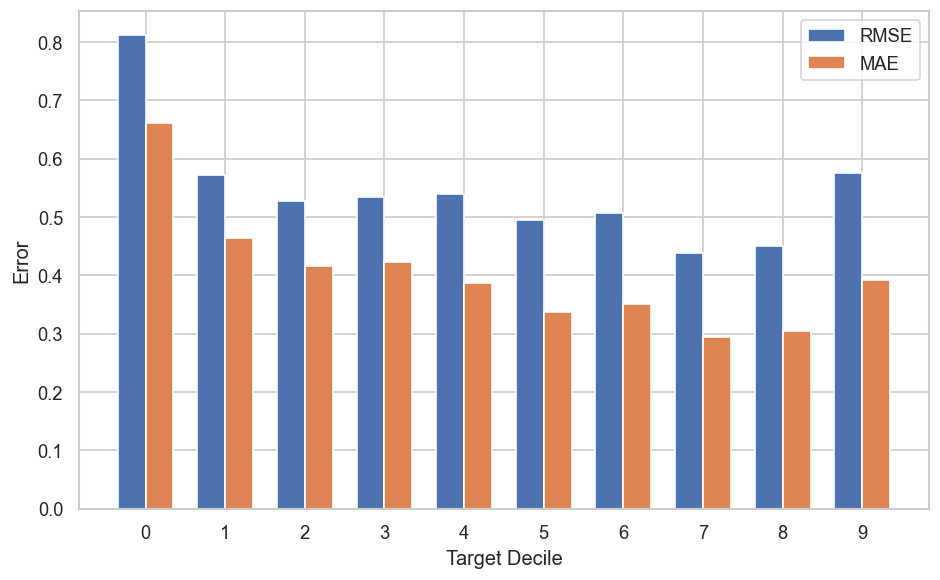

In [41]:
# Target-decile subgroup table (with mean residual)

merged["target_decile"] = pd.qcut(merged["y_true"], 10, labels=False, duplicates="drop")
dec = merged.groupby("target_decile").agg(
    n=("y_true", "size"),
    rmse=("residual", lambda s: round(float(np.sqrt(np.mean(np.square(s)))), 4)),
    mae=("abs_error", lambda s: round(float(np.mean(s)), 4)),
    mean_true=("y_true", lambda s: round(float(np.mean(s)), 4)),
    mean_pred=("y_pred", lambda s: round(float(np.mean(s)), 4)),
    mean_residual=("residual", lambda s: round(float(np.mean(s)), 4)),
).reset_index()

display(dec)

# Bar chart of RMSE and MAE by target decile
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,5))
bar_width = 0.35
x = np.arange(len(dec["target_decile"]))

ax.bar(x - bar_width/2, dec["rmse"], bar_width, label='RMSE')
ax.bar(x + bar_width/2, dec["mae"], bar_width, label='MAE')
ax.set_xlabel("Target Decile")
ax.set_ylabel("Error")
ax.set_xticks(x)
ax.set_xticklabels(dec["target_decile"])
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
# Save the bar plot of RMSE and MAE by target decile
fig_path = ETHICS_OUT_DIR / "barplot_error_by_target_decile.png"
fig.savefig(fig_path, dpi=150)
print("Saved:", fig_path)

Saved: outputs/ethics_bias_error_analysis/barplot_error_by_target_decile.png


In [43]:
# Save target-decile subgroup table

dec_path = ETHICS_OUT_DIR / "subgroup_error_by_target_decile.csv"
dec.to_csv(dec_path, index=False)
print("Saved:", dec_path)


Saved: outputs/ethics_bias_error_analysis/subgroup_error_by_target_decile.csv


### Subgroup errors by population decile

In [44]:
# Population-decile subgroup table
pop = None
if "a_inw" in merged.columns:
    merged["population_decile"] = pd.qcut(
        pd.to_numeric(merged["a_inw"], errors="coerce"),
        10,
        labels=False,
        duplicates="drop",
    )
    pop = merged.groupby("population_decile").agg(
        n=("y_true", "size"),
        rmse=("residual", lambda s: float(np.sqrt(np.mean(np.square(s))))),
        mae=("abs_error", "mean"),
        mean_true=("y_true", "mean"),
        mean_predicted=("y_pred", "mean"),
        mean_residual=("residual", "mean"),
    ).reset_index()

    # Reorder columns specifically as requested
    pop = pop[["population_decile", "n", "rmse", "mae", "mean_true", "mean_predicted", "mean_residual"]]

    display(pop.round(4))
else:
    print("a_inw not available; skipping population-decile table.")


,population_decile,n,rmse,mae,mean_true,mean_predicted,mean_residual
0,0,281,0.8889,0.6909,1.9045,1.9088,-0.0043
1,1,286,0.7242,0.5701,1.7703,1.7660,0.0043
2,2,271,0.6751,0.5432,1.9695,2.0395,-0.0701
3,3,268,0.6258,0.4807,2.4639,2.5103,-0.0464
4,4,275,0.4756,0.3664,2.8025,2.7816,0.0208
5,5,274,0.4861,0.3607,3.1927,3.2277,-0.0350
6,6,276,0.3720,0.2884,3.6300,3.6626,-0.0326
7,7,277,0.3854,0.2924,3.9125,3.8884,0.0241
8,8,275,0.2908,0.2255,4.3309,4.2828,0.0481
9,9,276,0.2882,0.2242,4.8394,4.8242,0.0152


In [45]:
# Save population-decile subgroup table

if pop is not None:
    pop_path = ETHICS_OUT_DIR / "subgroup_error_by_population_decile.csv"
    pop.to_csv(pop_path, index=False)
    print("Saved:", pop_path)


Saved: outputs/ethics_bias_error_analysis/subgroup_error_by_population_decile.csv


Saved plot: outputs/ethics_bias_error_analysis/population_decile_rmse_plot.png


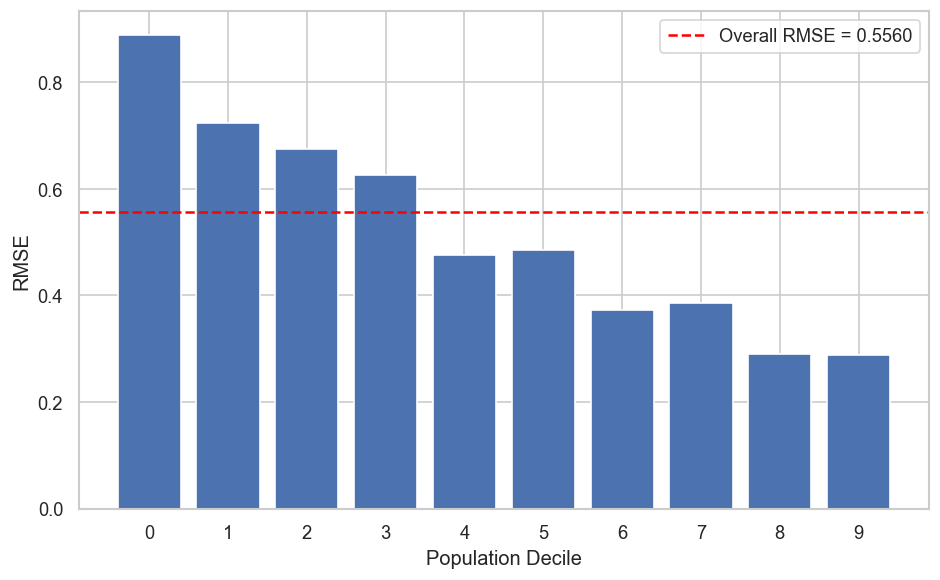

In [46]:
import matplotlib.pyplot as plt

if pop is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(pop["population_decile"].astype(str), pop["rmse"])
    ax.set_xlabel("Population Decile")
    ax.set_ylabel("RMSE")

    # Calculate overall test-set RMSE (from merged)
    overall_rmse = float(np.sqrt(np.mean(np.square(merged["residual"]))))
    ax.axhline(overall_rmse, color="red", linestyle="--", label=f"Overall RMSE = {overall_rmse:.4f}")
    ax.legend()

    plt.tight_layout()
    pop_plot_path = ETHICS_OUT_DIR / "population_decile_rmse_plot.png"
    plt.savefig(pop_plot_path, dpi=150, bbox_inches="tight")
    print("Saved plot:", pop_plot_path)
    plt.show()

### Municipality-level error summary

In [47]:
# Municipality-level error summary

if "gm_naam" in merged.columns:
    muni = merged.groupby("gm_naam").agg(
        n=("y_true", "size"),
        rmse=("residual", lambda s: float(np.sqrt(np.mean(np.square(s))))),
        mae=("abs_error", "mean"),
        mean_true=("y_true", "mean"),
        mean_pred=("y_pred", "mean"),
        mean_abs_error=("abs_error", "mean"),
    ).reset_index()

    display(muni.sort_values("rmse", ascending=False).round(4).head(30))
else:
    muni = None
    print("gm_naam not available; skipping municipality summary.")


,gm_naam,n,rmse,mae,mean_true,mean_pred,mean_abs_error
64,Zandvoort,19,0.9152,0.6949,3.6770,3.1410,0.6949
30,Lelystad,136,0.8041,0.5672,2.6653,2.5851,0.5672
60,Waterland,19,0.6790,0.4741,2.6490,2.9484,0.4741
48,Schiedam,70,0.6753,0.4484,4.0340,3.7641,0.4484
41,Oudewater,18,0.6664,0.5390,2.0447,2.2926,0.5390
34,Nieuwegein,39,0.6664,0.4130,4.3055,3.9441,0.4130
36,Noardeast-Fryslân,97,0.6402,0.5048,1.6171,1.7732,0.5048
49,Schouwen-Duiveland,51,0.6376,0.4712,2.5365,2.6165,0.4712
58,Voorschoten,12,0.6273,0.4635,3.9648,4.1552,0.4635
51,Someren,34,0.6203,0.4480,2.3176,2.2922,0.4480


In [48]:
# Save municipality-level error summary

if muni is not None:
    muni_path = ETHICS_OUT_DIR / "municipality_error_summary.csv"
    muni.to_csv(muni_path, index=False)
    print("Saved:", muni_path)


Saved: outputs/ethics_bias_error_analysis/municipality_error_summary.csv


### Residual and error diagnostics (all models)


In [49]:
# Residual summary per model (all models)

preds_df = preds.copy()

resid_summary = (
    preds_df.groupby(["dataset", "model", "tuning"])
    .agg(
        n=("y_true", "size"),
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        max_abs_error=("abs_error", "max"),
    )
    .reset_index()
    .sort_values(["dataset", "model", "tuning"])
)

display(resid_summary.round(4))

resid_summary_out = ETHICS_OUT_DIR / "residual_summary_by_model.csv"
resid_summary.to_csv(resid_summary_out, index=False)
print("Saved:", resid_summary_out)

,dataset,model,tuning,n,mean_residual,median_residual,mean_abs_error,median_abs_error,max_abs_error
0,base,OLS,mvp,2759,-0.0092,0.0203,0.5147,0.3981,4.2084
1,base,RF,mvp,2759,-0.0045,-0.0115,0.4206,0.3102,3.2518
2,base,RF,tuned,2759,-0.0065,-0.0170,0.4182,0.3106,3.2831
3,base,XGB,mvp,2759,-0.0043,-0.0054,0.4096,0.3035,3.1406
4,base,XGB,tuned,2759,-0.0094,-0.0119,0.4087,0.3042,3.5364
5,boundary,OLS,mvp,2759,-0.0045,0.0324,0.5168,0.4059,3.8959
6,boundary,RF,mvp,2759,-0.0016,-0.0094,0.4196,0.3092,3.2307
7,boundary,RF,tuned,2759,-0.0033,-0.0125,0.4201,0.3082,3.2917
8,boundary,XGB,mvp,2759,-0.0119,-0.0131,0.4102,0.2975,3.1506
9,boundary,XGB,tuned,2759,-0.0073,-0.0129,0.4050,0.2942,3.1839


Saved: outputs/ethics_bias_error_analysis/residual_summary_by_model.csv


### Worst predicted neighbourhoods

In [50]:
# Worst predicted neighbourhoods (best model)

worst = merged.sort_values("abs_error", ascending=False)
cols = [c for c in [
    "gwb_code_10",
    "gm_naam",
    "regio",
    "dataset",
    "model",
    "tuning",
    "y_true",
    "y_pred",
    "residual",
    "abs_error",
] if c in worst.columns]

display(worst[cols].head(20).round(4))

worst_out = ETHICS_OUT_DIR / "worst_predicted_neighbourhoods_top20.csv"
worst[cols].head(20).to_csv(worst_out, index=False)
print("Saved:", worst_out)


,gwb_code_10,gm_naam,regio,dataset,model,tuning,y_true,y_pred,residual,abs_error
566,BU03562300,Nieuwegein,Hoge Landen,boundary,XGB,tuned,4.8978,1.7139,3.1839,3.1839
2123,BU09950963,Lelystad,Stationsplein,boundary,XGB,tuned,5.6204,2.5142,3.1062,3.1062
1244,BU06060003,Schiedam,Walvisbuurt,boundary,XGB,tuned,6.9048,3.9262,2.9785,2.9785
2147,BU09951078,Lelystad,Larserplein,boundary,XGB,tuned,3.4340,0.7914,2.6425,2.6425
2156,BU09951098,Lelystad,Oostvaardersplassen,boundary,XGB,tuned,3.7612,1.1565,2.6047,2.6047
2102,BU09950732,Lelystad,"De Doelen, De Marken",boundary,XGB,tuned,4.1271,1.6105,2.5166,2.5166
2238,BU16401401,Leudal,Verspreide huizen Neeritter,boundary,XGB,tuned,0.0000,2.3210,-2.3210,2.3210
1577,BU08280905,Oss,Geffense Bosjes,boundary,XGB,tuned,3.2958,0.9934,2.3025,2.3025
2155,BU09951097,Lelystad,Hollandse Hout,boundary,XGB,tuned,2.8332,0.6252,2.2080,2.2080
1356,BU07360106,De Ronde Venen,Sportpark Mijdrecht,boundary,XGB,tuned,0.0000,2.1052,-2.1052,2.1052


Saved: outputs/ethics_bias_error_analysis/worst_predicted_neighbourhoods_top20.csv


### Municipality-level performance summaries (best model)


In [51]:
# Performance by municipality (best model, gm_naam)

if "gm_naam" in merged.columns:
    muni_perf = (
        merged.groupby("gm_naam")
        .agg(
            n=("y_true", "size"),
            mean_true=("y_true", "mean"),
            mean_pred=("y_pred", "mean"),
            mean_residual=("residual", "mean"),
            mae=("abs_error", "mean"),
            max_abs_error=("abs_error", "max"),
        )
        .reset_index()
    )
    muni_perf = muni_perf[muni_perf["n"] >= 5].sort_values("mae", ascending=False).reset_index(drop=True)

    display(muni_perf.round(4).head(30))

    muni_perf_out = ETHICS_OUT_DIR / "best_model_error_by_municipality.csv"
    muni_perf.to_csv(muni_perf_out, index=False)
    print("Saved:", muni_perf_out)
else:
    print("gm_naam not available; skipping municipality summary.")


,gm_naam,n,mean_true,mean_pred,mean_residual,mae,max_abs_error
0,Zandvoort,19,3.6770,3.1410,0.5360,0.6949,1.8217
1,Lelystad,136,2.6653,2.5851,0.0802,0.5672,3.1062
2,Oudewater,18,2.0447,2.2926,-0.2479,0.5390,1.4110
3,Ameland,7,2.4472,2.9340,-0.4868,0.5330,1.1270
4,Noardeast-Fryslân,97,1.6171,1.7732,-0.1560,0.5048,1.9512
5,Waterland,19,2.6490,2.9484,-0.2994,0.4741,1.6634
6,Schouwen-Duiveland,51,2.5365,2.6165,-0.0800,0.4712,1.9061
7,Súdwest-Fryslân,155,1.7216,1.8767,-0.1551,0.4708,1.7367
8,Voorschoten,12,3.9648,4.1552,-0.1904,0.4635,1.2572
9,Barendrecht,62,3.0010,2.9395,0.0615,0.4634,1.4834


Saved: outputs/ethics_bias_error_analysis/best_model_error_by_municipality.csv


### Error diagnostics plots (best model)

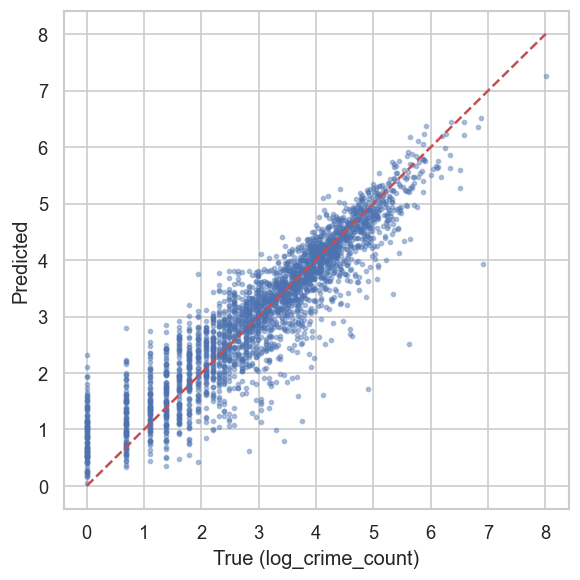

Saved: outputs/ethics_bias_error_analysis/figures/pred_vs_actual.png


In [52]:
fig_dir = ETHICS_OUT_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Figure: predicted vs actual (held-out test)
plt.figure(figsize=(5, 5))
plt.scatter(merged["y_true"], merged["y_pred"], alpha=0.4, s=6)
plt.xlabel("True (log_crime_count)")
plt.ylabel("Predicted")
plt.tight_layout()

fp = fig_dir / "pred_vs_actual.png"
plt.plot([merged["y_true"].min(), merged["y_true"].max()],
         [merged["y_true"].min(), merged["y_true"].max()],
         'r--', label='Actual')
plt.savefig(fp, dpi=200)
plt.show()
print("Saved:", fp)


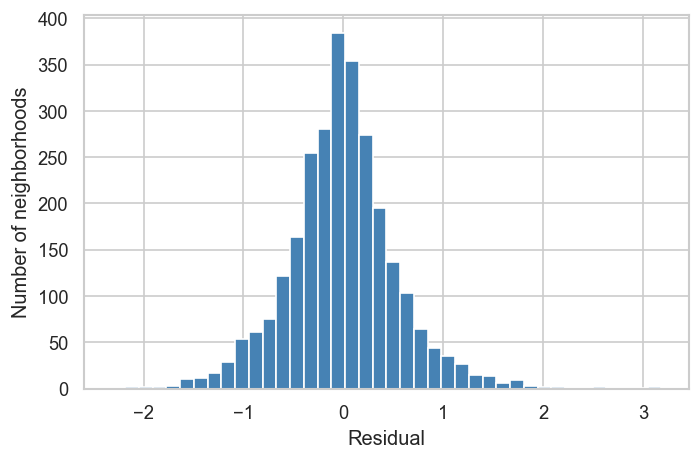

Saved: outputs/ethics_bias_error_analysis/figures/residual_hist.png


In [53]:
# Figure: residual histogram (held-out test)
plt.figure(figsize=(6, 4))
plt.hist(merged["residual"], bins=40, color="steelblue", edgecolor="white")
plt.xlabel("Residual")
plt.ylabel("Number of neighborhoods")
plt.tight_layout()
fr = fig_dir / "residual_hist.png"
plt.savefig(fr, dpi=200)
plt.show()
print("Saved:", fr)


In [54]:
# Compute residual statistics for the best performing model
residual_stats = {
    "mean": merged["residual"].mean(),
    "median": merged["residual"].median(),
    "std": merged["residual"].std(),
    "min": merged["residual"].min(),
    "max": merged["residual"].max(),
    "skew": merged["residual"].skew(),
    "kurtosis": merged["residual"].kurt()
}
residual_stats_df = pd.DataFrame([residual_stats]).T
residual_stats_df.columns = ["value"]
display(residual_stats_df)

# Save residual stats for reproducibility
residual_stats_out = ETHICS_OUT_DIR / "best_model_residual_stats.csv"
residual_stats_df.to_csv(residual_stats_out)
print("Saved:", residual_stats_out)

,value
mean,-0.007306
median,-0.012857
std,0.556054
min,-2.321015
max,3.183894
skew,0.369152
kurtosis,2.465104


Saved: outputs/ethics_bias_error_analysis/best_model_residual_stats.csv


### Error by true crime level (best model)


In [55]:
# Error by true crime level (best model, y_true quantiles)

q = pd.qcut(merged["y_true"], 5, labels=["very low", "low", "medium", "high", "very high"], duplicates="drop")
merged = merged.copy()
merged["true_level"] = q

by_level = (
    merged.groupby("true_level")
    .agg(
        n=("y_true", "size"),
        mean_true=("y_true", "mean"),
        mean_pred=("y_pred", "mean"),
        mean_residual=("residual", "mean"),
        rmse=("residual", lambda s: float(np.sqrt(np.mean(np.square(s))))),
        mae=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
    )
    .reset_index()
)

display(by_level.round(4))

by_level_out = ETHICS_OUT_DIR / "best_model_error_by_true_level.csv"
by_level.to_csv(by_level_out, index=False)
print("Saved:", by_level_out)


/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_41809/319891113.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("true_level")


,true_level,n,mean_true,mean_pred,mean_residual,rmse,mae,max_abs_error
0,very low,557,1.0370,1.4417,-0.4047,0.7084,0.5680,2.3210
1,low,558,2.3776,2.4577,-0.0801,0.5296,0.4189,1.8079
2,medium,540,3.1863,3.1063,0.0800,0.5182,0.3635,2.6425
3,high,559,3.9239,3.7869,0.1371,0.4752,0.3237,2.6047
4,very high,545,4.9081,4.6693,0.2388,0.5169,0.3486,3.1839


Saved: outputs/ethics_bias_error_analysis/best_model_error_by_true_level.csv


## Statistical comparison of held-out test performance

This is to compare models on the same held-out municipalities using paired prediction errors, while respecting the fact that neighbourhoods are clustered within municipalities.

### Municipality-cluster bootstrap + paired cluster permutation test

In [56]:
# ── helpers ───────────────────────────────────────────────────────────────────

PRED_PATH = MODEL_OUT_DIR / "test_set_predictions_all_models.csv"
preds_stat = pd.read_csv(PRED_PATH)

ID_COL, GROUP_COL = "gwb_code_10", "gm_naam"

required_cols = {ID_COL, GROUP_COL, "dataset", "model", "tuning", "y_true", "y_pred"}
if missing := required_cols - set(preds_stat.columns):
    raise ValueError(f"Missing columns: {missing}")


def _get_combo_predictions(preds, model, dataset, tuning):
    out = preds[(preds["model"] == model) & (preds["dataset"] == dataset) & (preds["tuning"] == tuning)].copy()
    if out.empty:
        raise ValueError(f"No predictions found for: {model}, {dataset}, {tuning}")
    return out[[ID_COL, GROUP_COL, "y_true", "y_pred"]].rename(columns={"y_pred": f"y_pred_{model}_{dataset}_{tuning}"})


def _prepare_pair(preds, left, right):
    left_df  = _get_combo_predictions(preds, *left)
    right_df = _get_combo_predictions(preds, *right)
    left_col, right_col = f"y_pred_{'_'.join(left)}", f"y_pred_{'_'.join(right)}"

    pair = left_df.merge(right_df, on=[ID_COL, GROUP_COL, "y_true"], how="inner", validate="one_to_one")
    if pair.empty:
        raise ValueError(f"No overlapping rows for {left} vs {right}")

    pair["se_left"]  = (pair["y_true"] - pair[left_col])  ** 2
    pair["se_right"] = (pair["y_true"] - pair[right_col]) ** 2
    return pair


def _rmse(se):
    return float(np.sqrt(np.mean(se)))


def cluster_bootstrap_rmse_diff(preds, left, right, n_boot=5000, random_state=42):
    rng  = np.random.default_rng(random_state)
    pair = _prepare_pair(preds, left, right)
    observed_diff = _rmse(pair["se_left"]) - _rmse(pair["se_right"])

    groups  = pair[GROUP_COL].dropna().unique()
    grouped = {g: df for g, df in pair.groupby(GROUP_COL)}

    boot_diffs = []
    for _ in range(n_boot):
        sample = pd.concat(
            [grouped[g] for g in rng.choice(groups, size=len(groups), replace=True)],
            ignore_index=True,
        )
        boot_diffs.append(_rmse(sample["se_left"]) - _rmse(sample["se_right"]))

    boot_diffs = np.array(boot_diffs)
    return {
        "rmse_diff_left_minus_right": observed_diff,
        "ci95_low":  float(np.percentile(boot_diffs, 2.5)),
        "ci95_high": float(np.percentile(boot_diffs, 97.5)),
    }


def cluster_permutation_rmse_diff(preds, left, right, n_perm=5000, random_state=42):
    rng  = np.random.default_rng(random_state)
    pair = _prepare_pair(preds, left, right)
    observed_diff = _rmse(pair["se_left"]) - _rmse(pair["se_right"])

    agg = pair.groupby(GROUP_COL).agg(n=("y_true", "size"), se_left_sum=("se_left", "sum"), se_right_sum=("se_right", "sum")).reset_index()
    n_total = int(agg["n"].sum())

    perm_diffs = []
    for _ in range(n_perm):
        swap = rng.random(len(agg)) < 0.5
        rmse_left  = np.sqrt(np.where(swap, agg["se_right_sum"], agg["se_left_sum"]).sum()  / n_total)
        rmse_right = np.sqrt(np.where(swap, agg["se_left_sum"],  agg["se_right_sum"]).sum() / n_total)
        perm_diffs.append(rmse_left - rmse_right)

    p = (np.sum(np.abs(perm_diffs) >= abs(observed_diff)) + 1) / (n_perm + 1)
    return {"permutation_p_value": float(p)}


def holm_adjust(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    order, adjusted, running_max = np.argsort(pvalues), np.empty(len(pvalues)), 0
    for rank, idx in enumerate(order):
        running_max = max(running_max, (len(pvalues) - rank) * pvalues[idx])
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


# ── comparisons ───────────────────────────────────────────────────────────────

comparisons = [
    # model family
    {"comparison_group": "model_family", "left": ("XGB", "base",     "tuned"), "right": ("RF",  "base",     "tuned"), "label": "XGB base vs RF base"},
    {"comparison_group": "model_family", "left": ("RF",  "base",     "tuned"), "right": ("OLS", "base",     "mvp"),   "label": "RF base vs OLS base"},
    {"comparison_group": "model_family", "left": ("XGB", "base",     "tuned"), "right": ("OLS", "base",     "mvp"),   "label": "XGB base vs OLS base"},
    {"comparison_group": "model_family", "left": ("XGB", "queen",    "tuned"), "right": ("RF",  "queen",    "tuned"), "label": "XGB queen vs RF queen"},
    {"comparison_group": "model_family", "left": ("XGB", "boundary", "tuned"), "right": ("RF",  "boundary", "tuned"), "label": "XGB boundary vs RF boundary"},
    # feature set
    {"comparison_group": "feature_set",  "left": ("XGB", "boundary", "tuned"), "right": ("XGB", "base",     "tuned"), "label": "XGB boundary vs XGB base"},
    {"comparison_group": "feature_set",  "left": ("XGB", "queen",    "tuned"), "right": ("XGB", "base",     "tuned"), "label": "XGB queen vs XGB base"},
    {"comparison_group": "feature_set",  "left": ("XGB", "boundary", "tuned"), "right": ("XGB", "queen",    "tuned"), "label": "XGB boundary vs XGB queen"},
    {"comparison_group": "feature_set",  "left": ("RF",  "queen",    "tuned"), "right": ("RF",  "base",     "tuned"), "label": "RF queen vs RF base"},
    {"comparison_group": "feature_set",  "left": ("RF",  "boundary", "tuned"), "right": ("RF",  "base",     "tuned"), "label": "RF boundary vs RF base"},
    {"comparison_group": "feature_set",  "left": ("RF",  "queen",    "tuned"), "right": ("RF",  "boundary", "tuned"), "label": "RF queen vs RF boundary"},
    {"comparison_group": "feature_set",  "left": ("OLS", "queen",    "mvp"),   "right": ("OLS", "base",     "mvp"),   "label": "OLS queen vs OLS base"},
    {"comparison_group": "feature_set",  "left": ("OLS", "boundary", "mvp"),   "right": ("OLS", "base",     "mvp"),   "label": "OLS boundary vs OLS base"},
    {"comparison_group": "feature_set",  "left": ("OLS", "queen",    "mvp"),   "right": ("OLS", "boundary", "mvp"),   "label": "OLS queen vs OLS boundary"},
]

# ── run ───────────────────────────────────────────────────────────────────────

rmse_diff_rows = []
for comp in comparisons:
    left, right = comp["left"], comp["right"]
    try:
        boot = cluster_bootstrap_rmse_diff(preds_stat, left=left, right=right, n_boot=5000, random_state=RANDOM_STATE)
        perm = cluster_permutation_rmse_diff(preds_stat, left=left, right=right, n_perm=5000, random_state=RANDOM_STATE)
        rmse_diff_rows.append({"comparison_group": comp["comparison_group"], "comparison": comp["label"], **boot, **perm})
    except Exception as e:
        print(f"Skipped {comp['label']}: {e}")

rmse_diff_df = pd.DataFrame(rmse_diff_rows)

if rmse_diff_df.empty:
    print("No comparisons computed.")
else:
    rmse_diff_df["holm_p_value"] = holm_adjust(rmse_diff_df["permutation_p_value"].values)
    rmse_diff_df["ci95_range"] = rmse_diff_df.apply(lambda r: f"[{r['ci95_low']:.5f}, {r['ci95_high']:.5f}]", axis=1)
    rmse_diff_df = (
        rmse_diff_df
        .drop(columns=["ci95_low", "ci95_high"])
        .sort_values(["comparison_group", "comparison"])
        .reset_index(drop=True)
    )

    display(rmse_diff_df.round(5))

    stat_out = MODEL_OUT_DIR / "heldout_test_cluster_statistical_comparisons.csv"
    rmse_diff_df.to_csv(stat_out, index=False)
    print("Saved:", stat_out)

,comparison_group,comparison,rmse_diff_left_minus_right,permutation_p_value,holm_p_value,ci95_range
0,feature_set,OLS boundary vs OLS base,-0.00122,0.64767,1.00000,"[-0.00680, 0.00368]"
1,feature_set,OLS queen vs OLS base,-0.00729,0.04599,0.36793,"[-0.01527, -0.00008]"
2,feature_set,OLS queen vs OLS boundary,-0.00607,0.02719,0.24475,"[-0.01166, -0.00090]"
3,feature_set,RF boundary vs RF base,0.00440,0.09518,0.66627,"[-0.00057, 0.00921]"
4,feature_set,RF queen vs RF base,0.00837,0.19276,1.00000,"[-0.00442, 0.01952]"
5,feature_set,RF queen vs RF boundary,0.00397,0.40812,1.00000,"[-0.00541, 0.01253]"
6,feature_set,XGB boundary vs XGB base,-0.00199,0.48250,1.00000,"[-0.00791, 0.00358]"
7,feature_set,XGB boundary vs XGB queen,-0.00495,0.18636,1.00000,"[-0.01134, 0.00206]"
8,feature_set,XGB queen vs XGB base,0.00296,0.54469,1.00000,"[-0.00609, 0.01150]"
9,model_family,RF base vs OLS base,-0.11098,0.00020,0.00280,"[-0.13944, -0.08842]"


Saved: outputs/modeling/heldout_test_cluster_statistical_comparisons.csv


## Outputs saved

### Train/test splits (written to `datasets/model_ready/`)
- `datasets/model_ready/model_ready_base_train.csv` / `datasets/model_ready/model_ready_base_test.csv`
- `datasets/model_ready/model_ready_queen_train.csv` / `datasets/model_ready/model_ready_queen_test.csv`
- `datasets/model_ready/model_ready_boundary_train.csv` / `datasets/model_ready/model_ready_boundary_test.csv`

### Modeling outputs (written to `outputs/modeling/`)
- `outputs/modeling/final_test_set_results.csv`
- `outputs/modeling/test_set_predictions_all_models.csv`
- `outputs/modeling/sensitivity_reduced_final_test_set_results.csv`
- `outputs/modeling/sensitivity_reduced_comparison_table.csv`

### Ethics / bias / error outputs (written to `outputs/ethics_bias_error_analysis/`)
- `overall_error_metrics.csv`
- `subgroup_error_by_target_decile.csv`
- `subgroup_error_by_population_decile.csv` (if `a_inw` available)
- figures under `outputs/ethics_bias_error_analysis/figures/`
